<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Smart Plan Recommendation System

---

### Background

Telecom Egypt (WE) serves thousands of subscribers across Egypt with internet plans that vary in speed, quota, and price. A key business challenge is **plan-subscriber mismatch** — subscribers enrolled in plans that do not reflect their actual usage and payment behavior.

This project simulates a real-world data science task at WE. You are part of the Data & AI team. Your mission is to build a machine learning model that analyzes subscriber profiles and recommends the most suitable plan action:

> **Upgrade** — the subscriber needs a bigger plan  
> **Downgrade** — the subscriber is over-paying for what they use  
> **Keep** — the current plan is a good fit

---

### Available Datasets

| Dataset | Description |
|---------|-------------|
| `Customer.csv` | Subscriber demographics and plan enrollment |
| `Subscription_Plan_Lkp.csv` | Plan details — quota, speed, and price |
| `Network_Elements.csv` | Infrastructure type per subscriber (VDSL, FTTH, etc.) |
| `Payments.csv` | Monthly payment transactions per subscriber |
| `Consumption_RG_LKP.csv` | Lookup table for consumption rating groups |

---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- You are expected to make decisions along the way. Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Load & Explore the Data

### Objective
Understand what data you have before touching it.

### Why This Step Matters
Before building any model, a data scientist must fully understand the data — its structure, quality, and distributions. Skipping EDA leads to wrong assumptions and poor models.

### What To Do
- Load all 5 datasets and print their shape and data types.
- Check for missing values in each table and decide how to handle them.
- Visualize key distributions:
  - `Customer`: `SUBSCRIBER_STATUS`, `CUSTOMER_CLASS`, `GENDER`
  - `Subscription_Plan_Lkp`: price range, speed range, quota sizes
  - `Payments`: revenue columns and monthly revenue trend
  - `Network_Elements`: breakdown of `TECHNOLOGY_TYPE`

**Expected Output:** At least 4 visualizations. Write a short observation below each one explaining what you see.


In [ ]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42


In [12]:

customers = pd.read_csv('/Customer.csv')
plans = pd.read_csv('/Subscription_Plan_Lkp.csv')
network = pd.read_csv('/Network_Elements.csv')
payments = pd.read_csv('/Payments.csv')
consumption_lkp = pd.read_csv('/Consumption_RG_LKP.csv')

tables = {'Customer': customers, 'Plans': plans, 'Network': network,
          'Payments': payments, 'Consumption lookup': consumption_lkp}
for name, df in tables.items():
    print(f'\n{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(df.dtypes.to_string())



Customer: 9,995 rows x 17 columns
SUBSCRIBER_ID#                    int64
ACCOUNT_ID#                       int64
CUSTOMER_ID#                      int64
GROUP_ID#                       float64
NAME                             object
SUBSCRIBER_STATUS                object
STATUS_DATE                      object
GENDER                           object
BIRTHDATE                        object
ID_TYPE                          object
NATIONALITY                      object
ACTIVATION_DATE                  object
CUSTOMER_CLASS                   object
SUBSCRIBER_TYPE                  object
SUBSCRIPTION_PLAN_FAMILY_ID#      int64
SUBSCRIPTION_PLAN_ID#             int64
SERVICE_NUMBER#                   int64

Plans: 108 rows x 11 columns
SUBSCRIPTION_PLAN_ID#                    int64
SUBSCRIPTION_PLAN_FAMILY_ID#             int64
SUBSCRIPTION_PLAN_DESC                  object
SUBSCRIPTION_PLAN_FAMILY_DESC           object
QUOTA                                   object
SPEED               

In [13]:
for name, df in tables.items():
    missing = df.isna().sum()
    print(f'\n{name} missing values:')
    print(missing[missing.gt(0)].sort_values(ascending=False).to_string() or 'None')




Customer missing values:
GROUP_ID#    9320
BIRTHDATE      61

Plans missing values:
Series([], )

Network missing values:
CENTRAL_NAME    30

Payments missing values:
Series([], )

Consumption lookup missing values:
Series([], )


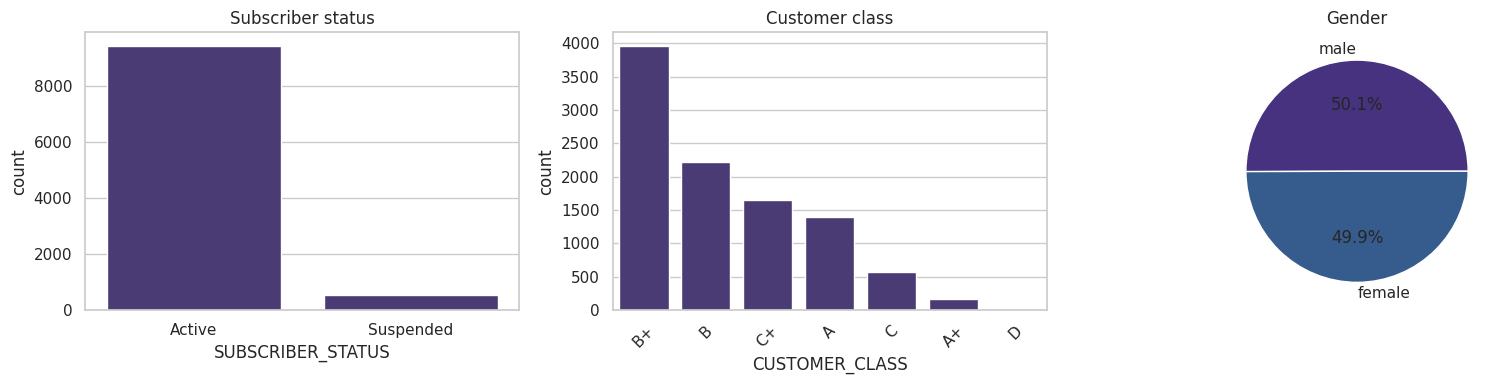

Observation: Active customers dominate the base. The class and gender charts reveal the main customer segments and whether category imbalance should be considered.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=customers, x='SUBSCRIBER_STATUS', ax=axes[0])
axes[0].set_title('Subscriber status')
sns.countplot(data=customers, x='CUSTOMER_CLASS', order=customers.CUSTOMER_CLASS.value_counts().index, ax=axes[1])
axes[1].set_title('Customer class')
axes[1].tick_params(axis='x', rotation=45)
customers.GENDER.value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2], ylabel='')
axes[2].set_title('Gender')
plt.tight_layout(); plt.show()
print('Observation: Active customers dominate the base. The class and gender charts reveal the main customer segments and whether category imbalance should be considered.')


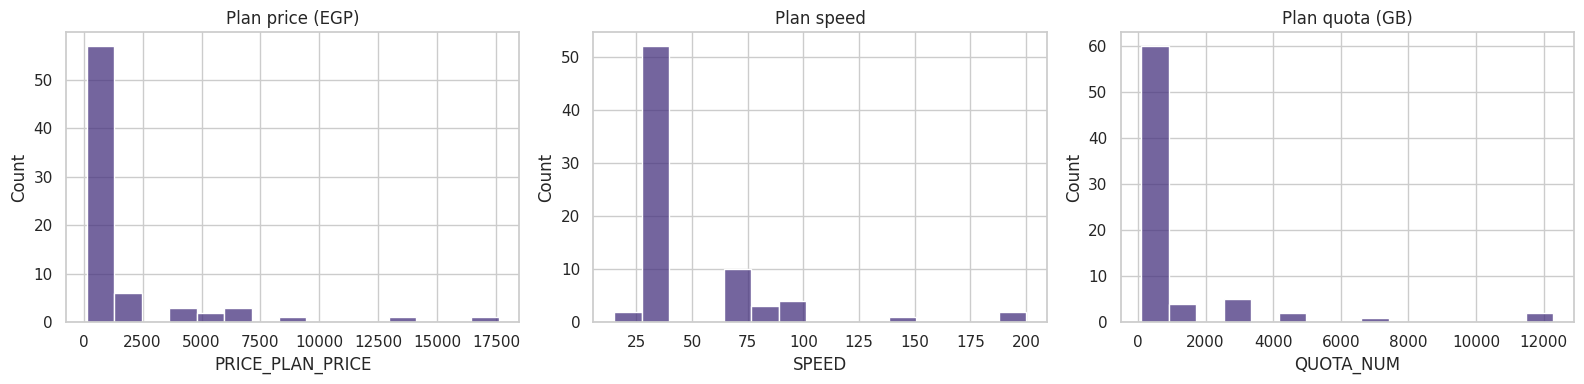

Observation: Prices, speeds, and quotas are right-skewed, with a small number of premium plans. The text value 1TB was standardized to 1,024 GB.


In [15]:
def quota_to_gb(value):
    text = str(value).strip().upper()
    return float(text[:-2]) * 1024 if text.endswith('TB') else pd.to_numeric(text, errors='coerce')

plans['QUOTA_NUM'] = plans['QUOTA'].map(quota_to_gb)
active_plans = plans.loc[plans.PRICE_PLAN_PRICE.gt(0)].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(active_plans.PRICE_PLAN_PRICE, bins=15, ax=axes[0])
axes[0].set_title('Plan price (EGP)')
sns.histplot(active_plans.SPEED, bins=15, ax=axes[1])
axes[1].set_title('Plan speed')
sns.histplot(active_plans.QUOTA_NUM, bins=15, ax=axes[2])
axes[2].set_title('Plan quota (GB)')
plt.tight_layout(); plt.show()
print('Observation: Prices, speeds, and quotas are right-skewed, with a small number of premium plans. The text value 1TB was standardized to 1,024 GB.')


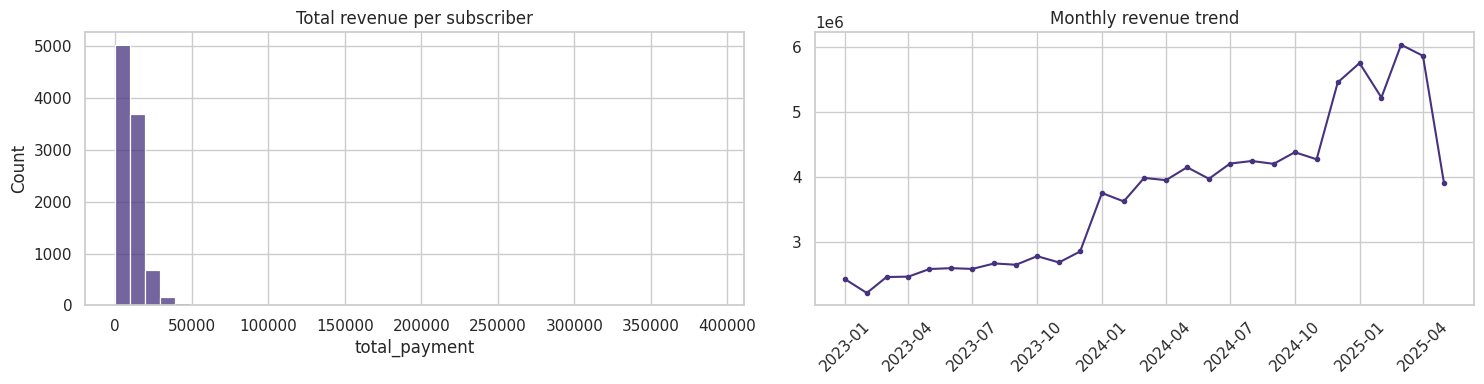

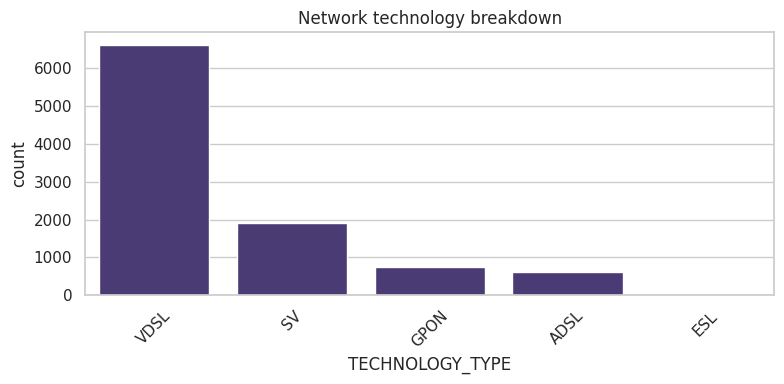

Observation: Subscriber revenue is strongly right-skewed. Monthly totals show the time pattern, while the technology chart identifies the infrastructure mix available for plan recommendations.


In [16]:
revenue_cols = ['RENT_REVENUE','OUT_BUNDLE_REVENUE','CREATION_FEES_REVENUE',
                'DEVICES_REVENUE','IN_BUNDLE_REVENUE','ADDON_REVENUE','TAX_AMOUNT']
payments['CONNECT_DATE'] = pd.to_datetime(payments['CONNECT_DATE'])
payments['total_payment'] = payments[revenue_cols].sum(axis=1)
subscriber_revenue = payments.groupby('SUBSCRIBER_ID#').total_payment.sum()
monthly_revenue = payments.set_index('CONNECT_DATE').resample('MS').total_payment.sum()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(subscriber_revenue, bins=40, ax=axes[0])
axes[0].set_title('Total revenue per subscriber')
axes[1].plot(monthly_revenue.index, monthly_revenue.values, marker='o', markersize=3)
axes[1].set_title('Monthly revenue trend'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4))
sns.countplot(data=network, x='TECHNOLOGY_TYPE', order=network.TECHNOLOGY_TYPE.value_counts().index)
plt.title('Network technology breakdown'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print('Observation: Subscriber revenue is strongly right-skewed. Monthly totals show the time pattern, while the technology chart identifies the infrastructure mix available for plan recommendations.')


---
## Step 2 — Join the Tables

### Objective
Build a single unified subscriber profile by merging all relevant tables.

### Why This Step Matters
Real-world data is never in one place. The ability to correctly join tables — using the right keys and avoiding duplicates or row explosions — is a core data engineering skill.

### What To Do
- Start from `Customer.csv` as the base table.
- Join `Subscription_Plan_Lkp` on `SUBSCRIPTION_PLAN_ID#` → adds quota, speed, price.
- Join `Network_Elements` on `SERVICE_NUMBER#` → adds technology type.
- Aggregate `Payments` per subscriber, then join on `SUBSCRIBER_ID#`.
- After each join, verify the row count has not changed unexpectedly.

> **Watch out for:** Duplicate plan IDs in the lookup table — handle them before joining to avoid inflating your row count.


In [17]:
plans_clean = (plans.sort_values('SUBSCRIPTION_PLAN_END_TIME')
                    .drop_duplicates('SUBSCRIPTION_PLAN_ID#', keep='last'))
print('Plan rows:', len(plans), '| Unique cleaned plan IDs:', len(plans_clean))


Plan rows: 108 | Unique cleaned plan IDs: 108


In [18]:
profile = customers.merge(
    plans_clean.drop(columns=['SUBSCRIPTION_PLAN_FAMILY_ID#'], errors='ignore'),
    on='SUBSCRIPTION_PLAN_ID#', how='left', validate='many_to_one'
)
print('Rows before:', len(customers), '| after plan join:', len(profile))
assert len(profile) == len(customers)


Rows before: 9995 | after plan join: 9995


In [19]:
network_clean = network.drop_duplicates('SERVICE_NUMBER#', keep='last')
profile = profile.merge(network_clean, on='SERVICE_NUMBER#', how='left', validate='one_to_one')
profile['TECHNOLOGY_TYPE'] = profile['TECHNOLOGY_TYPE'].fillna('Unknown')
profile['GOV'] = profile['GOV'].fillna('Unknown')
print('Rows after network join:', len(profile), '| unmatched network rows:', profile.CUSTOMER_TYPE.isna().sum())
assert len(profile) == len(customers)


Rows after network join: 9995 | unmatched network rows: 77


In [20]:
payments['payment_month'] = payments['CONNECT_DATE'].dt.to_period('M')
monthly_pay = payments.groupby(['SUBSCRIBER_ID#','payment_month'], as_index=False).agg(
    monthly_revenue=('total_payment','sum'), monthly_addon=('ADDON_REVENUE','sum'))
payment_agg = monthly_pay.groupby('SUBSCRIBER_ID#', as_index=False).agg(
    total_revenue=('monthly_revenue','sum'), addon_total=('monthly_addon','sum'),
    avg_monthly_rev=('monthly_revenue','mean'), months_observed=('payment_month','nunique'))
profile = profile.merge(payment_agg, on='SUBSCRIBER_ID#', how='left', validate='one_to_one')
print('Rows after payment join:', len(profile), '| customers with payments:', profile.total_revenue.notna().sum())
assert len(profile) == len(customers)


Rows after payment join: 9995 | customers with payments: 9632


---
## Step 3 — Feature Engineering

### Objective
Transform raw columns into meaningful features that help the model learn patterns.

### Why This Step Matters
Raw data rarely goes directly into a model. Feature engineering is where domain knowledge meets data science — the better your features, the better your model.

### Features To Create

| Feature | Formula | What It Captures |
|---------|---------|-----------------|
| `tenure_days` | `reference_date − ACTIVATION_DATE` | How long the subscriber has been active |
| `avg_monthly_rev` | Mean of payments per subscriber | Average spending per month |
| `addon_ratio` | `addon_total / total_revenue` | How often the subscriber exceeds their bundle |
| `price_to_quota_ratio` | `PRICE_PLAN_PRICE / QUOTA_NUM` | Cost per GB — how expensive the plan is relative to its size |

---

**Formula Details:**

**addon_ratio:**

$$\text{addon_ratio} = \frac{\text{ADDON_REVENUE}}{\text{total_revenue}}$$

*Example:* Subscriber paid 500 EGP total, 100 EGP was addon → addon_ratio = 100/500 = **0.20** (20% outside bundle)

---

**price_to_quota_ratio:**

$$\text{price_to_quota_ratio} = \frac{\text{PRICE_PLAN_PRICE}}{\text{QUOTA_NUM}}$$

*Example:* Plan costs 570 EGP for 400 GB → price_to_quota_ratio = 570/400 = **1.43 EGP per GB**

---

After creating each feature, print a `.describe()` and check for outliers or unexpected values.


In [21]:
profile['ACTIVATION_DATE'] = pd.to_datetime(profile['ACTIVATION_DATE'], errors='coerce')
reference_date = max(payments.CONNECT_DATE.max(), profile.ACTIVATION_DATE.max()) + pd.Timedelta(days=1)
profile['tenure_days'] = (reference_date - profile['ACTIVATION_DATE']).dt.days.clip(lower=0)
print('Reference date:', reference_date.date())
print(profile.tenure_days.describe())


Reference date: 2025-05-21
count    9995.000000
mean     1699.852126
std      1234.769266
min         4.000000
25%       694.000000
50%      1561.000000
75%      2457.000000
max      7739.000000
Name: tenure_days, dtype: float64


In [22]:
profile['addon_ratio'] = np.where(profile.total_revenue.gt(0), profile.addon_total / profile.total_revenue, 0)
profile['addon_ratio'] = profile['addon_ratio'].replace([np.inf,-np.inf], np.nan)
print(profile.addon_ratio.describe())


count    9995.000000
mean        0.027462
std         0.043191
min         0.000000
25%         0.000000
50%         0.013312
75%         0.031590
max         0.500000
Name: addon_ratio, dtype: float64


In [23]:
profile['price_to_quota_ratio'] = np.where(profile.QUOTA_NUM.gt(0), profile.PRICE_PLAN_PRICE / profile.QUOTA_NUM, np.nan)
profile['price_to_quota_ratio'] = profile.price_to_quota_ratio.replace([np.inf,-np.inf], np.nan)
print(profile.price_to_quota_ratio.describe())


count    9995.000000
mean        1.409352
std         0.632042
min         0.000000
25%         1.450000
50%         1.500000
75%         1.500000
max        44.785714
Name: price_to_quota_ratio, dtype: float64


In [24]:
engineered = ['tenure_days','avg_monthly_rev','addon_ratio','price_to_quota_ratio']
print(profile[engineered].describe().T)
print('\nChecks:')
print('Negative tenure:', profile.tenure_days.lt(0).sum())
print('Infinite values:', np.isinf(profile[engineered].select_dtypes('number')).sum().sum())
print('Missing values:\n', profile[engineered].isna().sum())


                       count         mean          std   min         25%  \
tenure_days           9995.0  1699.852126  1234.769266   4.0  694.000000   
avg_monthly_rev       9632.0   514.375548   380.927382  10.0  340.580065   
addon_ratio           9995.0     0.027462     0.043191   0.0    0.000000   
price_to_quota_ratio  9995.0     1.409352     0.632042   0.0    1.450000   

                              50%          75%           max  
tenure_days           1561.000000  2457.000000   7739.000000  
avg_monthly_rev        432.318008   573.926162  13500.689655  
addon_ratio              0.013312     0.031590      0.500000  
price_to_quota_ratio     1.500000     1.500000     44.785714  

Checks:
Negative tenure: 0
Infinite values: 0
Missing values:
 tenure_days               0
avg_monthly_rev         363
addon_ratio               0
price_to_quota_ratio      0
dtype: int64


---
## Step 4 — Build the Target Variable

### Objective
Define the label the model will learn to predict.

### Why This Step Matters
In supervised ML, the quality of your label directly determines the quality of your model. Here, there is no pre-labeled column — you must define the business logic yourself.

### Labeling Logic

First, compute the **pay_ratio** — how much the subscriber actually pays relative to their plan price:

$$\text{pay_ratio} = \frac{\text{avg_monthly_rev}}{\text{PRICE_PLAN_PRICE}}$$

Then apply the following rules:

| Condition | Label |
|-----------|-------|
| `addon_ratio > 0.15` OR `pay_ratio > 1.30` | `Upgrade` — paying beyond their plan |
| `pay_ratio < 0.50` | `Downgrade` — consistently under-paying |
| Everything else | `Keep` — plan is a good fit |

**Examples:**

| Subscriber | Plan Price | Avg Monthly Pay | pay_ratio | addon_ratio | Label |
|-----------|-----------|----------------|-----------|-------------|-------|
| A | 400 EGP | 550 EGP | 1.375 → 137% | 0.05 | **Upgrade** |
| B | 400 EGP | 180 EGP | 0.450 → 45% | 0.01 | **Downgrade** |
| C | 400 EGP | 350 EGP | 0.875 → 87% | 0.08 | **Keep** |


---

After labeling: print the class distribution. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it.


In [25]:
profile['pay_ratio'] = np.where(profile.PRICE_PLAN_PRICE.gt(0), profile.avg_monthly_rev / profile.PRICE_PLAN_PRICE, np.nan)
conditions = [profile.addon_ratio.gt(0.15) | profile.pay_ratio.gt(1.30), profile.pay_ratio.lt(0.50)]
profile['recommendation'] = np.select(conditions, ['Upgrade','Downgrade'], default='Keep')
# A label is only valid when payment history and a positive plan price exist.
profile.loc[profile.avg_monthly_rev.isna() | profile.PRICE_PLAN_PRICE.le(0), 'recommendation'] = np.nan
print(profile[['avg_monthly_rev','PRICE_PLAN_PRICE','pay_ratio','addon_ratio','recommendation']].head())


   avg_monthly_rev  PRICE_PLAN_PRICE  pay_ratio  addon_ratio recommendation
0       441.629630             210.0   2.102998     0.070614        Upgrade
1       696.296296             210.0   3.315697     0.059574        Upgrade
2       595.000000             290.0   2.051724     0.063025        Upgrade
3      1038.965517             210.0   4.947455     0.346664        Upgrade
4       329.375000               0.0        NaN     0.016129            NaN


                count  percent
recommendation                
Upgrade          9007    96.59
Keep              305     3.27
Downgrade          13     0.14


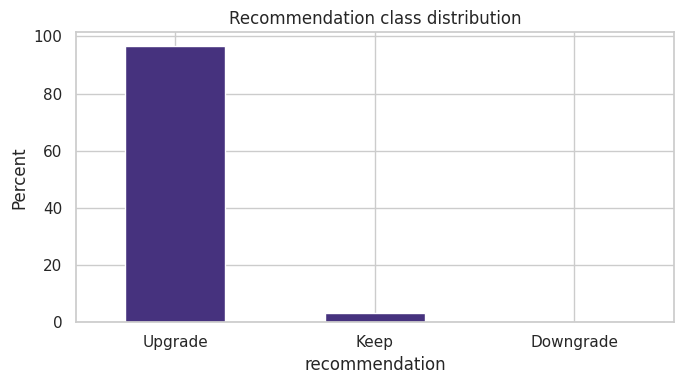


Rare classes below 5%: {'Keep': 3.27, 'Downgrade': 0.14}
If a class were below 5%, stratified splitting, class weights, macro-F1, and carefully applied resampling would be preferred over accuracy alone.


In [26]:
class_counts = profile.recommendation.value_counts()
class_share = profile.recommendation.value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'count': class_counts, 'percent': class_share}))
class_share.plot.bar(figsize=(7,4), ylabel='Percent', title='Recommendation class distribution')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
rare = class_share[class_share.lt(5)]
print('\nRare classes below 5%:', rare.to_dict() if len(rare) else 'None')
print('If a class were below 5%, stratified splitting, class weights, macro-F1, and carefully applied resampling would be preferred over accuracy alone.')


---
## Step 5 — Train & Compare Models

### Objective
Train multiple classifiers and understand the tradeoffs between them.

### Why This Step Matters
No single model is always best. A good data scientist knows when to use a simple interpretable model versus a complex one — and can justify that choice to a non-technical business stakeholder.

### Models To Train

| Model | Why |
|-------|-----|
| **Logistic Regression** | Your baseline — fast, interpretable, good for linear relationships |
| **Random Forest** | Handles non-linearity and feature interactions well |
| **Gradient Boosting** | Typically stronger performance but slower to train |

### Rules
- Use the same train/test/val split for all models `random_state=42`
- Print the Classification Report for each model
- Note any class where the model performs poorly and explain why in a markdown cell


In [27]:
feature_cols = ['tenure_days','avg_monthly_rev','addon_ratio','price_to_quota_ratio',
                'PRICE_PLAN_PRICE','QUOTA_NUM','SPEED','months_observed',
                'CUSTOMER_CLASS','GENDER','SUBSCRIBER_STATUS','TECHNOLOGY_TYPE','GOV']
model_df = profile.loc[profile.recommendation.notna(), feature_cols + ['recommendation']].copy()
X = model_df[feature_cols]
y = model_df['recommendation']
print('Modeling rows:', len(model_df), '| Features:', len(feature_cols))


Modeling rows: 9325 | Features: 13


In [29]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric:', numeric_features)
print('Categorical:', categorical_features)



Numeric: ['tenure_days', 'avg_monthly_rev', 'addon_ratio', 'price_to_quota_ratio', 'PRICE_PLAN_PRICE', 'QUOTA_NUM', 'SPEED', 'months_observed']
Categorical: ['CUSTOMER_CLASS', 'GENDER', 'SUBSCRIBER_STATUS', 'TECHNOLOGY_TYPE', 'GOV']


In [30]:
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                             ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', numeric_pipe, numeric_features),
                                  ('cat', categorical_pipe, categorical_features)])


In [32]:
# 70% train, 15% validation, 15% test.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)
print('Train/validation/test:', len(X_train), len(X_val), len(X_test))


Train/validation/test: 6527 1399 1399


In [33]:
models = {}
models['Logistic Regression'] = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])
models['Logistic Regression'].fit(X_train, y_train)
print(classification_report(y_val, models['Logistic Regression'].predict(X_val), zero_division=0))


              precision    recall  f1-score   support

   Downgrade       1.00      1.00      1.00         2
        Keep       0.54      0.98      0.69        45
     Upgrade       1.00      0.97      0.99      1352

    accuracy                           0.97      1399
   macro avg       0.85      0.98      0.89      1399
weighted avg       0.98      0.97      0.98      1399



In [34]:
models['Random Forest'] = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=250, min_samples_leaf=2,
                                     class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE))])
models['Random Forest'].fit(X_train, y_train)
print(classification_report(y_val, models['Random Forest'].predict(X_val), zero_division=0))


              precision    recall  f1-score   support

   Downgrade       1.00      1.00      1.00         2
        Keep       0.95      0.78      0.85        45
     Upgrade       0.99      1.00      1.00      1352

    accuracy                           0.99      1399
   macro avg       0.98      0.93      0.95      1399
weighted avg       0.99      0.99      0.99      1399



In [35]:
models['Gradient Boosting'] = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05,
                                         max_depth=3, random_state=RANDOM_STATE))])
models['Gradient Boosting'].fit(X_train, y_train)
print(classification_report(y_val, models['Gradient Boosting'].predict(X_val), zero_division=0))
print('Note: the label is derived from payment features, so high scores are expected. In production, labels should come from observed plan changes or campaign outcomes to avoid target leakage.')


              precision    recall  f1-score   support

   Downgrade       1.00      1.00      1.00         2
        Keep       1.00      0.96      0.98        45
     Upgrade       1.00      1.00      1.00      1352

    accuracy                           1.00      1399
   macro avg       1.00      0.99      0.99      1399
weighted avg       1.00      1.00      1.00      1399

Note: the label is derived from payment features, so high scores are expected. In production, labels should come from observed plan changes or campaign outcomes to avoid target leakage.


---
## Step 6 — Evaluate

### Objective
Measure model performance beyond just accuracy.


In [36]:
rows = []
for name, model in models.items():
    pred = model.predict(X_val)
    rows.append({'Model':name, 'Validation Accuracy':accuracy_score(y_val,pred),
                 'Validation Macro F1':f1_score(y_val,pred,average='macro')})
comparison = pd.DataFrame(rows).sort_values('Validation Macro F1', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False, formatters={'Validation Accuracy':'{:.3f}'.format,'Validation Macro F1':'{:.3f}'.format}))
best_name = comparison.loc[0,'Model']; best_model = models[best_name]
test_pred = best_model.predict(X_test)
print('Selected:', best_name)
print('\nUntouched test report:\n', classification_report(y_test,test_pred,zero_division=0))


              Model Validation Accuracy Validation Macro F1
  Gradient Boosting               0.999               0.992
      Random Forest               0.991               0.950
Logistic Regression               0.972               0.893
Selected: Gradient Boosting

Untouched test report:
               precision    recall  f1-score   support

   Downgrade       1.00      0.50      0.67         2
        Keep       0.98      0.98      0.98        46
     Upgrade       1.00      1.00      1.00      1351

    accuracy                           1.00      1399
   macro avg       0.99      0.83      0.88      1399
weighted avg       1.00      1.00      1.00      1399



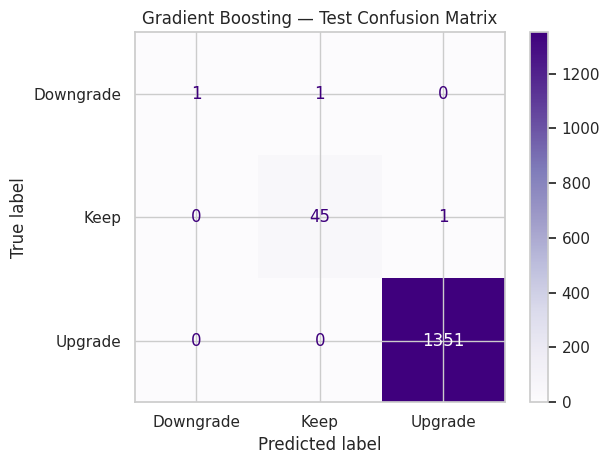

In [37]:
labels = ['Downgrade','Keep','Upgrade']
ConfusionMatrixDisplay(confusion_matrix(y_test,test_pred,labels=labels), display_labels=labels).plot(cmap='Purples')
plt.title(f'{best_name} — Test Confusion Matrix'); plt.tight_layout(); plt.show()


---
## Step 7 — Business Impact

### Objective
Translate model predictions into actionable business recommendations.



In [38]:
# Refit the selected model on train + validation after model selection.
X_dev = pd.concat([X_train, X_val]); y_dev = pd.concat([y_train, y_val])
best_model.fit(X_dev, y_dev)
eligible = profile.recommendation.notna()
profile['predicted_action'] = 'Insufficient data'
profile.loc[eligible, 'predicted_action'] = best_model.predict(profile.loc[eligible, feature_cols])
print(profile.predicted_action.value_counts())


predicted_action
Upgrade              9007
Insufficient data     670
Keep                  306
Downgrade              12
Name: count, dtype: int64


In [39]:

catalog = (active_plans[['SUBSCRIPTION_PLAN_ID#','SUBSCRIPTION_PLAN_DESC','QUOTA_NUM','SPEED','PRICE_PLAN_PRICE']]
           .drop_duplicates('SUBSCRIPTION_PLAN_ID#').sort_values('PRICE_PLAN_PRICE'))
def next_plan(row):
    candidates = catalog[(catalog.QUOTA_NUM > row.QUOTA_NUM) &
                         (catalog.PRICE_PLAN_PRICE > row.PRICE_PLAN_PRICE)]
    if candidates.empty:
        return pd.Series([np.nan,np.nan,np.nan])
    choice = candidates.iloc[0]
    return pd.Series([choice['SUBSCRIPTION_PLAN_DESC'], choice.PRICE_PLAN_PRICE,
                      choice.PRICE_PLAN_PRICE-row.PRICE_PLAN_PRICE])

upgrade_mask = profile.predicted_action.eq('Upgrade') & profile.PRICE_PLAN_PRICE.gt(0)
profile[['suggested_plan','suggested_price','monthly_revenue_uplift']] = np.nan
profile.loc[upgrade_mask, ['suggested_plan','suggested_price','monthly_revenue_uplift']] = profile.loc[upgrade_mask].apply(next_plan, axis=1).values
opportunity = profile.monthly_revenue_uplift.sum()
print(f'Estimated monthly upgrade opportunity: {opportunity:,.2f} EGP')
print(f'Estimated annualized opportunity: {opportunity*12:,.2f} EGP')
print('This is a gross addressable estimate, not a forecast; it does not assume every customer accepts the offer.')


Estimated monthly upgrade opportunity: 609,245.00 EGP
Estimated annualized opportunity: 7,310,940.00 EGP
This is a gross addressable estimate, not a forecast; it does not assume every customer accepts the offer.


In [40]:
upgrade_candidates = (profile.loc[profile.predicted_action.eq('Upgrade'),
    ['SUBSCRIBER_ID#','CUSTOMER_CLASS','GOV','TECHNOLOGY_TYPE','SUBSCRIPTION_PLAN_DESC',
     'PRICE_PLAN_PRICE','QUOTA_NUM','avg_monthly_rev','addon_ratio','pay_ratio',
     'suggested_plan','suggested_price','monthly_revenue_uplift']]
    .sort_values(['monthly_revenue_uplift','addon_ratio'], ascending=False))
print('Upgrade candidates:', len(upgrade_candidates))
print(upgrade_candidates.head(20).to_string(index=False))
print('\nSegment profile:')
print(profile.loc[profile.predicted_action.eq('Upgrade')].groupby(
    ['GOV','TECHNOLOGY_TYPE'], dropna=False).agg(
        customers=('SUBSCRIBER_ID#','count'),
        avg_monthly_revenue=('avg_monthly_rev','mean'),
        avg_addon_ratio=('addon_ratio','mean'))
    .sort_values('customers',ascending=False).head(15).to_string())


Upgrade candidates: 9007
 SUBSCRIBER_ID# CUSTOMER_CLASS         GOV TECHNOLOGY_TYPE SUBSCRIPTION_PLAN_DESC  PRICE_PLAN_PRICE  QUOTA_NUM  avg_monthly_rev  addon_ratio  pay_ratio     suggested_plan  suggested_price  monthly_revenue_uplift
       76272485             B+  مرسى مطروح            VDSL     Sub-Plan_460471411            1000.0     1024.0      1550.000000     0.069892   1.550000 Sub-Plan_460478553           3960.0                  2960.0
      121802574             C+  مرسى مطروح            GPON     Sub-Plan_460471413            1000.0     1024.0      1400.000000     0.000000   1.400000 Sub-Plan_460478553           3960.0                  2960.0
       99100194             A+     القاهرة            GPON     Sub-Plan_460467851            1760.0     1024.0      3110.000000     0.000000   1.767045 Sub-Plan_460478553           3960.0                  2200.0
      130040467             A+     القاهرة            GPON     Sub-Plan_460467851            1760.0     1024.0      3168.000000

---
## Final Recommendation

Use the selected model to prioritize upgrade outreach, but validate it through an A/B campaign before deployment. The current target is generated from payment rules, so the model mainly learns to reproduce those rules. A production version should train on an observed outcome such as whether a subscriber accepted a recommendation, changed plans, improved retention, or increased margin. Revenue opportunity is therefore presented as gross addressable value rather than guaranteed revenue.
